<a href="https://colab.research.google.com/github/isonikumari/Airbnb/blob/main/classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
mkdir -p ~/.kaggle && echo KGAT_b5b07078abae78ca269982a22e3b803b > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [12]:
import kagglehub


path = kagglehub.dataset_download(handle="moazeldsokyx/dogs-vs-cats")
print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
Dataset downloaded to: /kaggle/input/dogs-vs-cats


In [13]:
import os

print(f"Contents of {path}:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.1074.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.8997.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.9347.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.11995.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.11204.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.3946.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.1150.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.3499.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.9226.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.12378.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.9385.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.1594.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.928.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.9310.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.2998.jpg
/kaggle/input/dogs-vs-cats/dataset/train/cats/cat.3383.jpg
/ka

In [21]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [2]:
!pip install tensorflow

In [8]:
import os
import kagglehub

path = kagglehub.dataset_download(handle="moazeldsokyx/dogs-vs-cats")

train_ds = keras.utils.image_dataset_from_directory(
    directory=os.path.join(path, 'dataset', 'train'),
    labels='inferred',
    label_mode='binary',
    image_size=(128, 128),
    interpolation='nearest',
    batch_size=32,
    shuffle=True,
    seed=42
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=os.path.join(path, 'dataset', 'validation'),
    labels='inferred',
    label_mode='binary',
    image_size=(128, 128),
    interpolation='nearest',
    batch_size=32,
    shuffle=True,
    seed=42
)

# print("Training dataset created successfully!")
# print("Validation dataset created successfully!")

100%|██████████| 817M/817M [00:49<00:00, 17.2MB/s]

Extracting files...


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Training dataset created successfully!
Validation dataset created successfully!


In [12]:
def process(image,label):
   image=tf.cast(image/255. ,tf.float32)
   return image,label

   train_ds=train_ds.map(process)
   validation_ds=validation_ds.map(process)


In [22]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu",input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(64,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(128,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [27]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6492 - loss: 0.7403 - val_accuracy: 0.6990 - val_loss: 0.5571
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.7588 - loss: 0.5027 - val_accuracy: 0.7256 - val_loss: 0.5369
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8051 - loss: 0.4153 - val_accuracy: 0.6302 - val_loss: 0.6930
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.8484 - loss: 0.3434 - val_accuracy: 0.7908 - val_loss: 0.4551
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8737 - loss: 0.2847 - val_accuracy: 0.6574 - val_loss: 1.1026
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9000 - loss: 0.2277 - val_accuracy: 0.8168 - val_loss: 0.4577
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9255 - loss: 0.1743 - val_accuracy: 0.7760 - val_loss: 0.6470
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9394 - loss: 0.1449 - 

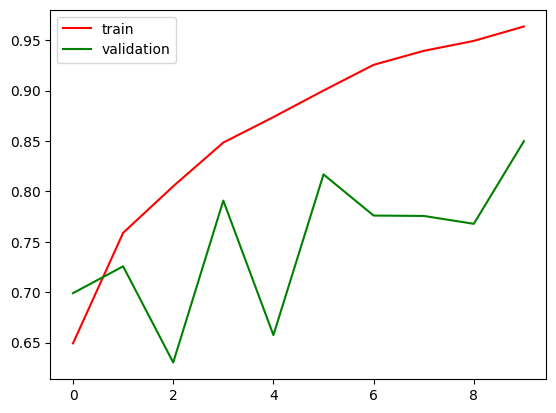

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'] , color="red",label="train")
plt.plot(history.history["val_accuracy"], color="green", label="validation")
plt.legend()
plt.show()

In [30]:
import numpy as np
from sklearn.metrics import f1_score


true_labels = []
predictions = []

for images, labels in validation_ds:
    true_labels.extend(labels.numpy())
    preds = model.predict(images)
    predictions.extend(preds)

binary_predictions = (np.array(predictions) > 0.5).astype(int)

true_labels = np.array(true_labels)


f1 = f1_score(true_labels, binary_predictions)
print(f"F1-score on the validation set: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━